## Some EDA and Data Preprocessing for Classification

In [63]:
%pip install -q numpy pandas matplotlib scikit-learn imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

# Hide convergence warnings from scikit-learn logs
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder


df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# 3. Define Features (X) and Target (y)
X = df.drop('stroke', axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_train = pd.DataFrame(
    encoder.fit_transform(X_train[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_train.index
)

encoded_test = pd.DataFrame(
    encoder.transform(X_test[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X_test.index
)

X_train = pd.concat([X_train.drop(categorical_cols, axis=1), encoded_train], axis=1)
X_test = pd.concat([X_test.drop(categorical_cols, axis=1), encoded_test], axis=1)

imputer = SimpleImputer(strategy='median')

X_train['bmi'] = imputer.fit_transform(X_train[['bmi']])
X_test['bmi'] = imputer.transform(X_test[['bmi']]) # Notice we only use .transform() on the test set

scaler = StandardScaler()
num_cols = ['age', 'avg_glucose_level', 'bmi']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Input Features: {X.columns}")
print(f"Target Column: {y.name}")

print(f"Training Set Size: {X_train.shape}, Testing Set Size: {X_test.shape}")

Input Features: Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status'],
      dtype='object')
Target Column: stroke
Training Set Size: (4088, 16), Testing Set Size: (1022, 16)


c:\Users\srira\Python\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Class Imbalance

In *Data_Preprocessing.ipynb* in the *Intro,EDA and Preprocessing folder* we have covered majority of all the preprocessing techniques to be applied before feeding any dataset to an ML model. The same applies for classification tasks as well, but there is another key point to keep in mind for classification datasets, which is **Class Imbalance**.

**Class Imbalance** refers to a scenario in a classification problem where the dataset's classes are not distributed equally, meaning one class significantly outnumbers the other(s).

**Problem with class imbalance**:
- Any model trained on this data will be biased towards the majority class.
- The metrics are not reliable when data is biased towards the majority class.
*Example:* For the given dataset a model biased towards majority class i.e. *no stroke* will give us very high accuracy, but it does not mean it will predict well to identify a person with stroke.

stroke
0    3901
1     187
Name: count, dtype: int64
stroke
0    95.425636
1     4.574364
Name: count, dtype: float64


<Axes: xlabel='stroke'>

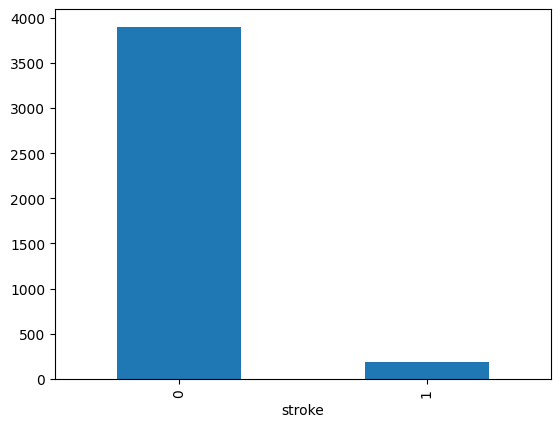

In [66]:
print(y_train.value_counts())

print(y_train.value_counts()/sum(y_train.value_counts())*100)

y_train.value_counts().plot(kind='bar')

### Solving Class Imbalance

#### Undersampling

**Balance an uneven dataset by reducing the number of examples from the abundant class (the majority class) to match the rare class (the minority class)**

![Undersampling](./assets/undersampling.png)

**Advantages:**
- Reduction in bias
- Faster training due to less datapoints

**Disadvantages:**
- Information loss leading to underfitting
- Sampling Bias i.e. sampling might introduce some type of bias in picking datapoints

stroke
0    187
1    187
Name: count, dtype: int64
stroke
0    50.0
1    50.0
Name: count, dtype: float64


<Axes: xlabel='stroke'>

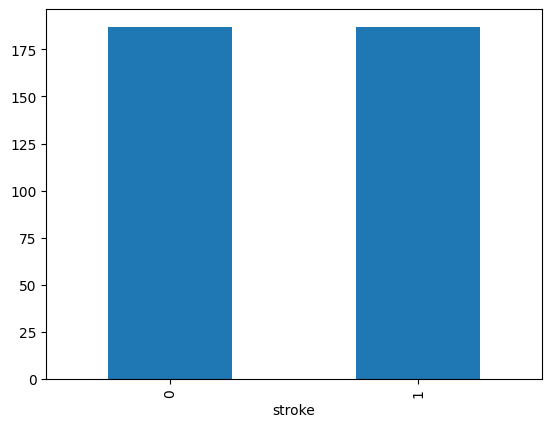

In [67]:
from  imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(sampling_strategy=1, random_state=42) 
# Here sampling_strategy=0.5 means that we want the minority class 
# to be 50% of the majority class after undersampling.

X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

print(y_train_under.value_counts())
print(y_train_under.value_counts()/sum(y_train_under.value_counts())*100)
y_train_under.value_counts().plot(kind='bar')

#### Random Oversampling

**Randomly duplicates existing data points from the minority class until the classes have an equal number of records.**

![Random Oversampling](./assets/oversampling.png)

**Advantages:**
- Reduction in bias

**Disadvantages:**
- Increased dataset size leading to more training time.
- Duplication of data may lead to overfitting, i.e. repeating the datapoint may make the model think that this datapoint is very important.

stroke
0    3901
1    3901
Name: count, dtype: int64
stroke
0    50.0
1    50.0
Name: count, dtype: float64


<Axes: xlabel='stroke'>

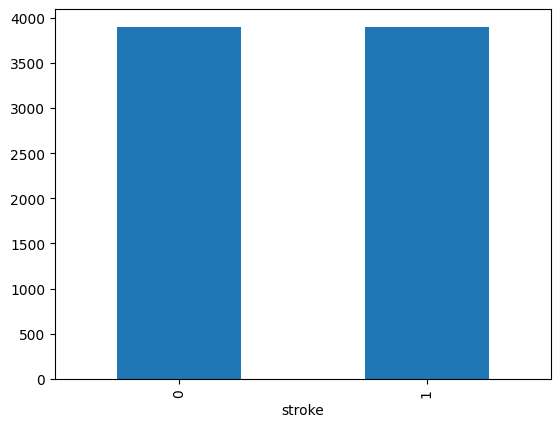

In [68]:
from  imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(sampling_strategy=1, random_state=42) 
# Here sampling_strategy=0.5 means that we want the minority class 
# to be 50% of the majority class after oversampling.

X_train_over, y_train_over = oversampler.fit_resample(X_train, y_train)

print(y_train_over.value_counts())
print(y_train_over.value_counts()/sum(y_train_over.value_counts())*100)
y_train_over.value_counts().plot(kind='bar')

#### Synthetic Minority Oversampling Technique (SMOTE)

**Instead of copying existing minority samples (which can cause overfitting), SMOTE builds realistic new data points through feature space interpolation**

**Algorithm Steps**
- Randomly pick a minority class datapoint, let this be $x_m$
- Now find *k* datapoints closest to this datapoint
- Randomly pick a neighbour from these *k* neighbours, let this be $x_d$
- Let us now select a random number between 0 and 1, let this be $f$
- Hence,
  $$
  x_{new} = x_m - f(x_m - x_d)
  $$


**Advantages:**
- Reduction in bias
- No duplication of data

**Disadvantages:**
- Does not handle categorical data well
- Computational complexity
- Dependent on choice of neighbours i.e. if very low k then less variety in generated datapoints, and if k is large then very high variety indicating scenarios which may not be possible. Generally *k = 5* is a conventionally good choice.
- Sensitive to outliers
- The balance achieved due to this may not match the true nature of distribution as this is a synthetic data generation method.

stroke
0    3901
1    3901
Name: count, dtype: int64
stroke
0    50.0
1    50.0
Name: count, dtype: float64


<Axes: xlabel='stroke'>

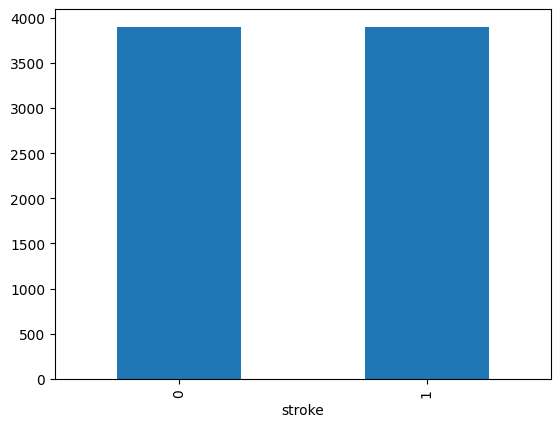

In [69]:
from  imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42) 
# Here sampling_strategy=0.5 means that we want the minority class 
# to be 50% of the majority class after SMOTE sampling.

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())
print(y_train_smote.value_counts()/sum(y_train_smote.value_counts())*100)
y_train_smote.value_counts().plot(kind='bar')

#### Ensemble Undersampling

**It works by partitioning the majority class data into multiple non-overlapping subsets and combining each subset with the minority class data to create several perfectly balanced training subsets, which are then used train models independently and aggregated.**

![Ensemble](./assets/ensemble.png)

**Advantages:**
- Reduction in bias
- Preserves valuable information

**Disadvantages:**
- More number of models to train leading to more training time.

## Metrics for Regression and Classification

### Regression

**Question:** Are Mean Absolute Error (MAE), Mean Square Error (MSE), Root Mean Square Error (RMSE) metrics or objective functions for optimisations ?

**R² Score (Coefficient of Determination)**

`1 - (SSR / SSM)`
SSR = `Σ(yᵢ - ŷᵢ)²`
SSM = `Σ(yᵢ - y_mean)²`

Also called "Goodness of Fit" — measures how much better the regression line performs compared to a simple mean baseline. A score of 1 means zero error; 0 means the model performs like the mean baseline; negative means it performs worse than the baseline. Its main flaw: adding irrelevant input features can artificially maintain or increase the score.


### Classification

A **confusion matrix** is a table used to evaluate the performance of a classification model by comparing the actual class labels with the model's predicted labels.

|  | **Predicted Negative** | **Predicted Positive** |
| --- | ---: | ---: |
| **Actual Negative** | **True Negative (TN)** | **False Positive (FP)** |
| **Actual Positive** | **False Negative (FN)** | **True Positive (TP)** |

- **True Negative (TN):** The model correctly predicts the negative class.
- **False Positive (FP):** The model incorrectly predicts the positive class for a negative example. This is also called a **Type I error**.
- **False Negative (FN):** The model incorrectly predicts the negative class for a positive example. This is also called a **Type II error**.
- **True Positive (TP):** The model correctly predicts the positive class.

For example, in the stroke dataset, **positive** means that the patient has had a stroke and **negative** means that the patient has not had a stroke. Therefore, a false negative means that the model fails to identify a patient who has had a stroke.

### Classification Metrics

The following metrics are calculated from the confusion matrix:

| Metric | What it means for the model | Formula | When to use it |
| --- | --- | --- | --- |
| **Accuracy** | The percentage of all samples that the model predicted correctly. | $$\frac{TP + TN}{TP + TN + FP + FN}$$ | Use when the classes are reasonably balanced and errors in both classes are equally important. It can be misleading for imbalanced datasets. |
| **Precision** | Of all samples predicted as positive, the percentage that are actually positive. | $$\frac{TP}{TP + FP}$$ | Use when false positives are costly. For example, use it when acting on a positive prediction is expensive or disruptive. |
| **Recall (Sensitivity)** | Of all actual positive samples, the percentage that the model correctly identified. | $$\frac{TP}{TP + FN}$$ | Use when false negatives are costly and missing a positive case is dangerous, such as failing to identify a patient with a stroke. |
| **Specificity** | Of all actual negative samples, the percentage that the model correctly identified as negative. | $$\frac{TN}{TN + FP}$$ | Use when false positives are costly and it is important to correctly rule out negative cases. |
| **F1 Score** | A single score that balances precision and recall by taking their harmonic mean. | $$2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$ | Use when the classes are imbalanced and both false positives and false negatives matter. It is especially useful when a balance between precision and recall is needed. |

For the stroke dataset, **recall** is often especially important because a false negative means failing to identify a patient who has had a stroke. However, the best metric depends on the consequences of false positives and false negatives in the application.

### Micro-F1 and Macro-F1

F1 score can be averaged across classes in different ways. This is particularly useful for multi-class or multi-label classification problems.

| Metric | What it means for the model | How it is computed | When to use it |
| --- | --- | --- | --- |
| **Micro-F1** | Measures the overall balance between precision and recall by giving equal importance to every individual prediction. | First add the TP, FP, and FN values across all classes, then calculate: $$F1_{micro} = \frac{2TP_{micro}}{2TP_{micro} + FP_{micro} + FN_{micro}}$$ | Use when every sample is equally important and you want the majority classes to have more influence according to their number of samples. |
| **Macro-F1** | Measures the average performance across classes by giving every class equal importance, regardless of its size. | Calculate the F1 score separately for each class, then take their arithmetic mean: $$F1_{macro} = \frac{1}{K}\sum_{i=1}^{K}F1_i$$ | Use when performance on minority classes is as important as performance on majority classes, especially for imbalanced datasets. |

For a binary classification problem, micro-F1 is closely related to the overall F1 score. Macro-F1 averages the F1 score for the positive class and the negative class, so it can reveal poor performance on one class even when the overall score looks good.

### ROC Curve and ROC-AUC Score

The **Receiver Operating Characteristic (ROC) curve** shows how well a classification model separates the positive and negative classes across different probability thresholds.

- The **x-axis** is the **False Positive Rate (FPR)**: $$FPR = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$
- The **y-axis** is the **True Positive Rate (TPR)**, also called recall or sensitivity: $$TPR = \frac{TP}{TP + FN}$$
- Each point on the curve is obtained by choosing a different probability threshold for converting predicted probabilities into positive or negative labels.

**How the ROC curve is computed:**

1. The model produces a probability score for the positive class for every sample, such as 0.82 or 0.31.
2. Choose a threshold, for example 0.50. Scores at or above the threshold are predicted as positive; the remaining scores are predicted as negative.
3. Use the resulting confusion matrix to calculate the FPR and TPR.
4. Repeat this for many thresholds, from a very high threshold to a very low threshold, and plot each `(FPR, TPR)` pair.
5. Join the points to form the ROC curve.

The **ROC-AUC score** is the **Area Under the ROC Curve**. It summarizes the entire ROC curve in a single number and measures the model's ability to rank positive samples above negative samples.

- **AUC = 1.0:** Perfect separation between positive and negative samples.
- **AUC = 0.5:** Performance equivalent to random guessing.
- **AUC < 0.5:** The ranking is worse than random; reversing the model's ranking would perform better.

A higher ROC-AUC means that the model generally assigns higher probability scores to positive samples than to negative samples. ROC-AUC is useful when comparing models across many classification thresholds or when the decision threshold has not yet been fixed. It can be less informative when the negative class is much larger and performance on the positive class is the main concern; in that situation, also consider the Precision-Recall curve and average precision.

In this notebook, `roc_auc_score(y_test, y_probs)` uses the true labels and the model's predicted probabilities for the positive class. `RocCurveDisplay.from_predictions(y_test, y_probs)` computes and plots the ROC curve using the same values.

Classification Report for Undersampled Model:
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       960
           1       0.16      0.81      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.93      0.73      0.80      1022

ROC-AUC Score: 0.8466

--- Generating ROC Curve Plot ---


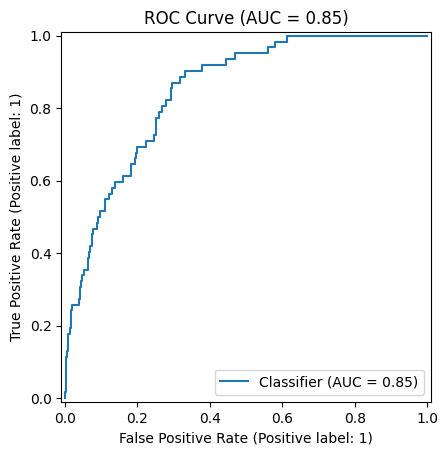

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

under_model = LogisticRegression(max_iter=1000, random_state=42)

under_model.fit(X_train_under, y_train_under)

y_pred_under = under_model.predict(X_test)
classification_report_under = classification_report(y_test, y_pred_under)

print("Classification Report for Undersampled Model:")

# 1. Generate hard labels and soft probabilities
y_probs_under = under_model.predict_proba(X_test)[:, 1]

# 2. Print Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_under))

# 3. Calculate and Print ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs_under)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 4. Plot the ROC Curve
print("\n--- Generating ROC Curve Plot ---")
RocCurveDisplay.from_predictions(y_test, y_probs_under)
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()


Classification Report for Random Oversampled Model:
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       960
           1       0.17      0.84      0.28        62

    accuracy                           0.74      1022
   macro avg       0.58      0.79      0.56      1022
weighted avg       0.94      0.74      0.81      1022

ROC-AUC Score: 0.8518

--- Generating ROC Curve Plot ---


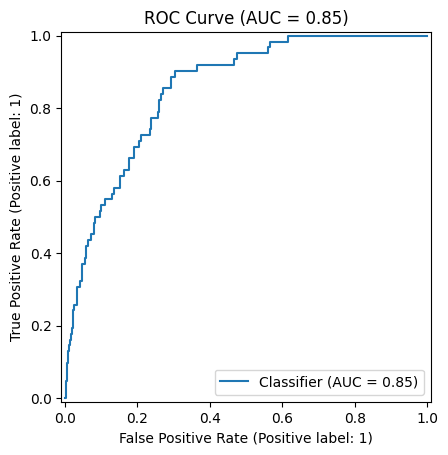

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

over_model = LogisticRegression(max_iter=1000, random_state=42)

over_model.fit(X_train_over, y_train_over)

y_pred_over = over_model.predict(X_test)
classification_report_over = classification_report(y_test, y_pred_over)

print("Classification Report for Random Oversampled Model:")

# 1. Generate hard labels and soft probabilities
y_probs_over = over_model.predict_proba(X_test)[:, 1]

# 2. Print Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_over))

# 3. Calculate and Print ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs_over)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 4. Plot the ROC Curve
print("\n--- Generating ROC Curve Plot ---")
RocCurveDisplay.from_predictions(y_test, y_probs_over)
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()


Classification Report for SMOTE Model:
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       960
           1       0.16      0.68      0.26        62

    accuracy                           0.77      1022
   macro avg       0.57      0.72      0.56      1022
weighted avg       0.92      0.77      0.82      1022

ROC-AUC Score: 0.8040

--- Generating ROC Curve Plot ---


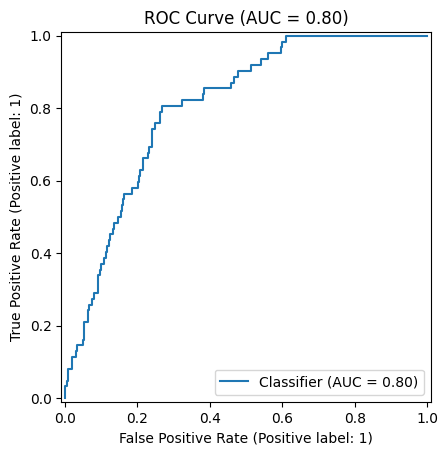

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

smote_model = LogisticRegression(max_iter=1000, random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
classification_report_smote = classification_report(y_test, y_pred_smote)

print("Classification Report for SMOTE Model:")

# 1. Generate hard labels and soft probabilities
y_probs_smote = smote_model.predict_proba(X_test)[:, 1]

# 2. Print Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred_smote))

# 3. Calculate and Print ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs_smote)
print(f"ROC-AUC Score: {auc_score:.4f}")

# 4. Plot the ROC Curve
print("\n--- Generating ROC Curve Plot ---")
RocCurveDisplay.from_predictions(y_test, y_probs_smote)
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()
